# UCS420 Cognitive Computing - Assignment 7

## NLP I (Text preprocessing)

Name: Vishu Verma

Roll number: 1024170242

Starter notebook cells (generate_dataset and process_ticket) are kept as given.

# UCS420 Lab Assignment 9 - NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024170242 # <-- your full roll number
NAME = "Vishu Verma" # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator - do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline - do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170242   Name: Vishu Verma   Fingerprint: 28B1E1DF   Tickets: 14

Ticket_ID                                                                            Ticket_Text
      T01                                  The MATLAB crashes while opening. Can you check this?
      T02                                                            My roll no. is 1023-03-021.
      T03  Wi-Fi has stopped syncing after restarting the system. The same problem occurs again.
      T04                                        The e-mail is showing an error. This is urgent.
      T05                             The Matlab keeps disconnecting. I don't know what changed.
      T06                                  Matlab is showing an error on my laptop. Please help.
      T07 MATLAB is running slowly before the assignment deadline. It works on another computer.
      T08                                      The laptop crashes while opening. This is urgent.
      T09                                   

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
results = {tid: process_ticket(text) for tid, text in zip(df.Ticket_ID, df.Ticket_Text)}

rows = []
for tid, r in results.items():
    rows.append({
        "Ticket_ID": tid,
        "Sentences": len(r["sentences"]),
        "Tokens": len(r["tokens"]),
        "Punctuation": len(r["punct"]),
        "Stopwords": len(r["stops"]),
        "Unique_Tokens": len(set(r["tokens"])),
        "Final_Tokens": len(r["final"]),
    })
table = pd.DataFrame(rows)

total = table.drop(columns="Ticket_ID").sum()
total["Ticket_ID"] = "TOTAL"
table = pd.concat([table, pd.DataFrame([total])], ignore_index=True)
print(table.to_string(index=False))

all_tokens = [t for r in results.values() for t in r["tokens"]]
# TOTAL of Unique_Tokens just adds the per ticket values, actual unique count over all tickets:
print("\nUnique tokens across all tickets:", len(set(all_tokens)))

Ticket_ID  Sentences  Tokens  Punctuation  Stopwords  Unique_Tokens  Final_Tokens
      T01          2      11            2          5             11             4
      T02          2       7            2          3              6             2
      T03          2      15            2          6             13             7
      T04          2      11            2          5              9             4
      T05          2      12            2          4             11             6
      T06          2      12            2          4             11             6
      T07          2      15            2          5             14             8
      T08          2      10            2          4              9             4
      T09          1       9            1          2              9             6
      T10          2      10            2          4              9             4
      T11          1      11            2          5              8             4
      T12       

**Selected ticket** (first FOCUS ticket)

In [6]:
sel = FOCUS[0]
r = results[sel]
print(f"Ticket {sel}:", df.loc[df.Ticket_ID == sel, "Ticket_Text"].item())
print("\nSentences  :", r["sentences"])
print("Tokens      :", r["tokens"])
print("Punctuation :", r["punct"])
print("Stopwords   :", r["stops"])
print("Final tokens:", r["final"])

Ticket T07: MATLAB is running slowly before the assignment deadline. It works on another computer.

Sentences  : ['MATLAB is running slowly before the assignment deadline.', 'It works on another computer.']
Tokens      : ['matlab', 'is', 'running', 'slowly', 'before', 'the', 'assignment', 'deadline', '.', 'it', 'works', 'on', 'another', 'computer', '.']
Punctuation : ['.', '.']
Stopwords   : ['is', 'before', 'the', 'it', 'on']
Final tokens: ['matlab', 'running', 'slowly', 'assignment', 'deadline', 'works', 'another', 'computer']


In [7]:
# final tokens which are not normal words
for tid, r in results.items():
    odd = [t for t in r["final"] if not t.isalpha()]
    if odd:
        print(tid, odd, " <-", df.loc[df.Ticket_ID == tid, "Ticket_Text"].item())

T02 ['1023-03-021']  <- My roll no. is 1023-03-021.
T03 ['wi-fi']  <- Wi-Fi has stopped syncing after restarting the system. The same problem occurs again.
T04 ['e-mail']  <- The e-mail is showing an error. This is urgent.
T05 ["n't"]  <- The Matlab keeps disconnecting. I don't know what changed.
T09 ['11', '5.30', 'p.m.']  <- I need Windows 11 by 5.30 p.m. today.
T11 ["'s", "'s"]  <- It's not the laptop; it's the server.


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:* In my data `n't` and `'s` are not real words.

- `n't` comes from "don't" in T05. word_tokenize splits it into `do` + `n't`. `do` is a stopword but `n't` is not in the NLTK stopword list, so it stays in the final tokens.
- `'s` comes from "It's" in T11 (twice). It gets split into `it` + `'s`, `it` is removed as a stopword but `'s` stays.

Also `p.m.`, `11`, `5.30` and `1023-03-021` are not dictionary words. There is no "can't" in my tickets so `ca` does not come up.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [8]:
import re

# L and R stop the word patterns from matching parts of emails/urls (like "it" in it.helpdesk@...)
L = r"(?<![\w.@/'-])"
R = r"(?![\w@/-]|['.]\w)"

LONG_WORD = L + r"[A-Za-z]{6,}" + R                            # longer than 5 letters
NUMBER    = r"(?<![\w.])\d+(?:[.,]\d+)*(?!\w)"                 # 11, 95.5, 2.0.1, 1,250
CAPITAL   = L + r"[A-Z][A-Za-z]*(?:['-][A-Za-z]+)*" + R          # Wi-Fi, It's, MATLAB
VOWEL     = L + r"[AEIOUaeiou][A-Za-z]*(?:['-][A-Za-z]+)*" + R   # e-mail, isn't, error

EMAIL = r"(?<![\w.+-])[\w.+-]+@[\w-]+(?:\.[\w-]+)+"
URL   = r"\b(?:https?://|www\.)\S+?(?=[.,;:!?)]*(?:\s|$))"     # full stop at the end not included
PHONE = r"(?<![\w+])(?:\+\d{1,3}[\s-]?\d{5}[\s-]?\d{5}|0\d{2,4}-\d{3,4}-\d{4})(?!\d)"

def extract(text):
    return {
        "longer than 5": re.findall(LONG_WORD, text),
        "numbers": re.findall(NUMBER, text),
        "capitalized": re.findall(CAPITAL, text),
        "vowel start": re.findall(VOWEL, text),
    }

def redact(text):
    text = re.sub(EMAIL, "<EMAIL>", text)   # emails first
    text = re.sub(URL, "<URL>", text)
    return re.sub(PHONE, "<PHONE>", text)

**On the TEST_LINES**

In [9]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

for line in TEST_LINES:
    print(line)
    for name, found in extract(line).items():
        print(f"  {name:14s}: {found}")
    print("  redacted      :", redact(line))
    print()

Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
  longer than 5 : []
  numbers       : []
  capitalized   : ['Mail']
  vowel start   : ['or', 'or']
  redacted      : Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>.

Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
  longer than 5 : ['Version']
  numbers       : ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']
  capitalized   : ['Call', 'Version', 'Rs']
  vowel start   : ['or', 'is']
  redacted      : Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.

The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
  longer than 5 : []
  numbers       : ['5.30']
  capitalized   : ['The']
  vowel start   : ["isn't", 'open', 'at']
  redacted      : The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.



**On my tickets**

In [10]:
for tid, text in zip(df.Ticket_ID, df.Ticket_Text):
    print(tid, text)
    for name, found in extract(text).items():
        if found:
            print(f"     {name:14s}: {found}")

T01 The MATLAB crashes while opening. Can you check this?
     longer than 5 : ['MATLAB', 'crashes', 'opening']
     capitalized   : ['The', 'MATLAB', 'Can']
     vowel start   : ['opening']
T02 My roll no. is 1023-03-021.
     numbers       : ['1023', '03', '021']
     capitalized   : ['My']
     vowel start   : ['is']
T03 Wi-Fi has stopped syncing after restarting the system. The same problem occurs again.
     longer than 5 : ['stopped', 'syncing', 'restarting', 'system', 'problem', 'occurs']
     capitalized   : ['Wi-Fi', 'The']
     vowel start   : ['after', 'occurs', 'again']
T04 The e-mail is showing an error. This is urgent.
     longer than 5 : ['showing', 'urgent']
     capitalized   : ['The', 'This']
     vowel start   : ['e-mail', 'is', 'an', 'error', 'is', 'urgent']
T05 The Matlab keeps disconnecting. I don't know what changed.
     longer than 5 : ['Matlab', 'disconnecting', 'changed']
     capitalized   : ['The', 'Matlab', 'I']
     vowel start   : ['I']
T06 Matlab is sh

In [11]:
all_text = "\n".join(df.Ticket_Text)
for name, found in extract(all_text).items():
    print(f"{name:14s} ({len(found):2d}): {found}")

print("\nTickets changed by re.sub():")
changed = [(tid, t, redact(t)) for tid, t in zip(df.Ticket_ID, df.Ticket_Text) if redact(t) != t]
print(changed if changed else "none (no email/url/phone in my tickets)")
print("The roll number in", df.Ticket_ID[df.Ticket_Text.str.contains("roll")].item(),
      "is left alone:", redact(df.Ticket_Text[df.Ticket_Text.str.contains("roll")].item()))

longer than 5  (49): ['MATLAB', 'crashes', 'opening', 'stopped', 'syncing', 'restarting', 'system', 'problem', 'occurs', 'showing', 'urgent', 'Matlab', 'disconnecting', 'changed', 'Matlab', 'showing', 'laptop', 'Please', 'MATLAB', 'running', 'slowly', 'before', 'assignment', 'deadline', 'another', 'computer', 'laptop', 'crashes', 'opening', 'urgent', 'Windows', 'password', 'working', 'Please', 'resolve', 'laptop', 'server', 'Student', 'portal', 'working', 'yesterday', 'mobile', 'hotspot', 'Please', 'Submitted', 'projector', 'stopped', 'responding', 'Please']
numbers        ( 5): ['1023', '03', '021', '11', '5.30']
capitalized    (30): ['The', 'MATLAB', 'Can', 'My', 'Wi-Fi', 'The', 'The', 'This', 'The', 'Matlab', 'I', 'Matlab', 'Please', 'MATLAB', 'It', 'The', 'This', 'I', 'Windows', 'The', 'Please', "It's", 'Student', 'I', 'Please', 'The', 'LMS', 'Submitted', 'The', 'Please']
vowel start    (31): ['opening', 'is', 'after', 'occurs', 'again', 'e-mail', 'is', 'an', 'error', 'is', 'urgent

In [12]:
# capitalized at sentence start vs other places
start, other = [], []
for text in df.Ticket_Text:
    for sent in sent_tokenize(text):
        for m in re.finditer(CAPITAL, sent):
            (start if m.start() == 0 else other).append(m.group())
# words like I, MATLAB, Wi-Fi are capital anyway, not just because of sentence start
always = lambda w: w == "I" or any(ch.isupper() for ch in w[1:]) or w in other
only_start = [w for w in start if not always(w)]
print(f"Capitalized words in total: {len(start) + len(other)}")
print(f"At the start of a sentence ({len(start)}):", start)
print(f"  ...of which capitalized ONLY because of the sentence start ({len(only_start)}):", only_start)
print(f"  ...of which would be capitalized anyway ({len(start) - len(only_start)}):", [w for w in start if always(w)])
print(f"Capitalized in the middle of a sentence ({len(other)}):", other)

Capitalized words in total: 30
At the start of a sentence (24): ['The', 'Can', 'My', 'Wi-Fi', 'The', 'The', 'This', 'The', 'I', 'Matlab', 'Please', 'MATLAB', 'It', 'The', 'This', 'I', 'The', 'Please', "It's", 'Student', 'Please', 'The', 'The', 'Please']
  ...of which capitalized ONLY because of the sentence start (19): ['The', 'Can', 'My', 'The', 'The', 'This', 'The', 'Please', 'It', 'The', 'This', 'The', 'Please', "It's", 'Student', 'Please', 'The', 'The', 'Please']
  ...of which would be capitalized anyway (5): ['Wi-Fi', 'I', 'Matlab', 'MATLAB', 'I']
Capitalized in the middle of a sentence (6): ['MATLAB', 'Matlab', 'Windows', 'I', 'LMS', 'Submitted']


**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:* There are 30 capitalized words in total and 24 of them are at the start of a sentence. Out of these, 19 are capital only because they start the sentence (The x8, This x2, Please x4, Can, My, It, It's, Student). The other 5 (Wi-Fi, Matlab, MATLAB, I, I) would be capital anyway. So most capital letters in the tickets don't mean the word is a name.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [13]:
from nltk.tokenize import RegexpTokenizer

PATTERN = r"""(?x)
    (?:https?://|www\.)\S+?(?=[.,;:!?)]*(?:\s|$))   # URLs, without trailing punctuation
  | [\w.+-]+@[\w-]+(?:\.[\w-]+)+                     # email addresses
  | \+\d{1,3}[\s-]?\d{5}[\s-]?\d{5}                  # phone with country code: +91 98765 43210
  | \b0\d{2,4}-\d{3,4}-\d{4}\b                       # landline: 0175-239-3201
  | \d+(?:[.,]\d+)+                                  # decimals, versions, 1,250
  | (?:[A-Za-z]\.){2,}                               # abbreviations like p.m.
  | \w+(?:[-']\w+)*                                  # words, contractions, hyphenated words
  | \.\.\.|[!?]+|[^\w\s]                              # ellipsis, !!! / ??, any other symbol
"""
_tokenizer = RegexpTokenizer(PATTERN)

def my_tokenize(text):
    return _tokenizer.tokenize(text)

In [14]:
def compare(text):
    mine, wt = my_tokenize(text), word_tokenize(text)
    print(text)
    print("  my_tokenize  :", mine)
    print("  word_tokenize:", wt)
    if mine != wt:
        print("  only mine    :", [t for t in mine if t not in wt])
        print("  only wt      :", [t for t in wt if t not in mine])
    print()
    return mine != wt

for line in TEST_LINES:
    compare(line)

Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
  my_tokenize  : ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
  word_tokenize: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
  only mine    : ['it.helpdesk@thapar.edu', 'a.b-c@dept.univ.ac.in', 'https://lms.thapar.edu/help']
  only wt      : ['it.helpdesk', '@', 'thapar.edu', 'a.b-c', '@', 'dept.univ.ac.in', 'https', ':', '//lms.thapar.edu/help']

Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
  my_tokenize  : ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
  word_tokenize: ['Call', '+91', '98765', '432

In [15]:
different = [tid for tid, text in zip(df.Ticket_ID, df.Ticket_Text) if compare(text)]
print("Tickets tokenized differently:", different, f"({len(different)} of {len(df)})")

The MATLAB crashes while opening. Can you check this?
  my_tokenize  : ['The', 'MATLAB', 'crashes', 'while', 'opening', '.', 'Can', 'you', 'check', 'this', '?']
  word_tokenize: ['The', 'MATLAB', 'crashes', 'while', 'opening', '.', 'Can', 'you', 'check', 'this', '?']

My roll no. is 1023-03-021.
  my_tokenize  : ['My', 'roll', 'no', '.', 'is', '1023-03-021', '.']
  word_tokenize: ['My', 'roll', 'no', '.', 'is', '1023-03-021', '.']

Wi-Fi has stopped syncing after restarting the system. The same problem occurs again.
  my_tokenize  : ['Wi-Fi', 'has', 'stopped', 'syncing', 'after', 'restarting', 'the', 'system', '.', 'The', 'same', 'problem', 'occurs', 'again', '.']
  word_tokenize: ['Wi-Fi', 'has', 'stopped', 'syncing', 'after', 'restarting', 'the', 'system', '.', 'The', 'same', 'problem', 'occurs', 'again', '.']

The e-mail is showing an error. This is urgent.
  my_tokenize  : ['The', 'e-mail', 'is', 'showing', 'an', 'error', '.', 'This', 'is', 'urgent', '.']
  word_tokenize: ['The', '

**Differences between my_tokenize() and word_tokenize()**

1. Contractions: word_tokenize splits isn't into `is` + `n't` and don't (T05) into `do` + `n't`. Mine keeps `isn't` and `don't` as one token.
2. It's (T11): word_tokenize gives `It` + `'s`, mine keeps `It's`. word_tokenize follows Penn Treebank rules which separate the 's and n't parts.
3. Emails: word_tokenize breaks it.helpdesk@thapar.edu into `it.helpdesk`, `@`, `thapar.edu` since it treats @ as punctuation. Mine keeps the full email.
4. URLs: word_tokenize splits https://lms.thapar.edu/help at the colon into `https`, `:`, `//lms.thapar.edu/help`. Mine keeps it as one.
5. Phone with spaces: +91 98765 43210 becomes 3 tokens in word_tokenize, 1 in mine.

Both give the same result for Wi-Fi, state-of-the-art, 95.5, 2.0.1, p.m., 0175-239-3201 and +91-98765-43210.

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:* 2 out of 14 tickets: T05 (don't) and T11 (It's / it's). Both are because of contractions. My tickets don't have any email, url or phone number, so the other 12 come out the same.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [16]:
import nltk
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

final_tokens = [t for r in results.values() for t in r["final"]]
unique_final = sorted(set(final_tokens))
print(len(unique_final), "unique final tokens:")
print(unique_final)

# words ending in -ing
print("\nEnding in -ing:", [w for w in unique_final if w.endswith("ing")])

54 unique final tokens:
["'s", '1023-03-021', '11', '5.30', 'another', 'assignment', 'changed', 'check', 'computer', 'crashes', 'deadline', 'disconnecting', 'e-mail', 'error', 'help', 'hotspot', 'keeps', 'know', 'laptop', 'lms', 'matlab', 'mobile', "n't", 'need', 'occurs', 'opening', 'p.m.', 'password', 'please', 'portal', 'problem', 'projector', 'resolve', 'responding', 'restarting', 'roll', 'running', 'says', 'server', 'showing', 'slowly', 'stopped', 'student', 'submitted', 'syncing', 'system', 'today', 'urgent', 'use', 'wi-fi', 'windows', 'working', 'works', 'yesterday']

Ending in -ing: ['disconnecting', 'opening', 'responding', 'restarting', 'running', 'showing', 'syncing', 'working']


**Suffix for RegexpStemmer: `ing$` (min=6)**

8 of my unique final tokens end with -ing: opening, syncing, restarting, showing, disconnecting, running, working, responding. That is the most common suffix in my data, and removing it gives the correct root for most of them (syncing -> sync, showing -> show, restarting -> restart). min=6 so that short words like "king" or "ring" don't get cut.

In [17]:
# pos tag each ticket's tokens (so the tag uses context), keep first tag for each word
pos_of = {}
for text in df.Ticket_Text:
    for word, tag in nltk.pos_tag([t for s in sent_tokenize(text) for t in word_tokenize(s)]):
        pos_of.setdefault(word.lower(), tag)

def to_wordnet(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

porter, lancaster = PorterStemmer(), LancasterStemmer()
regexp = RegexpStemmer("ing$", min=6)
lemmatizer = WordNetLemmatizer()

stem_rows = []
for w in unique_final:
    tag = pos_of[w]
    stem_rows.append({
        "Word": w, "POS": tag,
        "Porter": porter.stem(w),
        "Lancaster": lancaster.stem(w),
        "Regexp": regexp.stem(w),
        "WordNet": lemmatizer.lemmatize(w, to_wordnet(tag)),
    })
stems = pd.DataFrame(stem_rows)

outputs = ["Porter", "Lancaster", "Regexp", "WordNet"]
differ = stems[stems[outputs].nunique(axis=1) > 1]
print(f"Words where the four outputs differ: {len(differ)} of {len(stems)}\n")
print(differ.to_string(index=False))

Words where the four outputs differ: 31 of 54

      Word POS    Porter Lancaster     Regexp    WordNet
   another  DT     anoth     anoth    another    another
assignment  JJ    assign    assign assignment assignment
   changed VBD     chang     chang    changed     change
  computer  NN    comput    comput   computer   computer
   crashes NNS     crash     crash    crashes      crash
  deadline  NN   deadlin   deadlin   deadline   deadline
     error  NN     error        er      error      error
     keeps VBZ      keep      keep      keeps       keep
       lms NNP        lm       lms        lms         lm
    mobile  JJ     mobil      mobl     mobile     mobile
      need VBP      need       nee       need       need
    occurs VBZ     occur       occ     occurs      occur
   opening VBG      open        op       open       open
    please NNP     pleas     pleas     please     please
    portal  NN    portal      port     portal     portal
 projector  NN projector   project  proje

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:* Over-stemming: Lancaster gives projector -> project and portal -> port, which are different words with different meaning. It also cuts error -> er and student -> stud.

Under-stemming: my regexp stemmer (ing$) gives working -> work but works stays works, so the two forms of the same word don't match. Also running -> runn instead of run.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

In [18]:
from collections import Counter
import math
import matplotlib.pyplot as plt

S1 = [t for r in results.values() for t in r["tokens"]]
S2 = [t for t in S1 if not is_punct(t)]
S3 = [t for r in results.values() for t in r["final"]]
S4 = [porter.stem(t) for t in S3]

stats = pd.DataFrame(
    [{"Set": name, "Total tokens": len(s), "Unique tokens": len(set(s)), "TTR": round(len(set(s)) / len(s), 4)}
     for name, s in [("S1 all tokens", S1), ("S2 no punctuation", S2), ("S3 final tokens", S3), ("S4 S3 + Porter", S4)]]
)
print(stats.to_string(index=False))

              Set  Total tokens  Unique tokens    TTR
    S1 all tokens           153             81 0.5294
S2 no punctuation           125             77 0.6160
  S3 final tokens            72             54 0.7500
   S4 S3 + Porter            72             53 0.7361


In [19]:
print("Top 10 words of S1:")
for w, c in Counter(S1).most_common(10):
    print(f"  {w!r:12} {c}")
print("\nTop 10 words of S3:")
for w, c in Counter(S3).most_common(10):
    print(f"  {w!r:12} {c}")

Top 10 words of S1:
  '.'          24
  'the'        12
  'is'         7
  'matlab'     4
  'please'     4
  'it'         4
  'this'       3
  'i'          3
  'laptop'     3
  'help'       3

Top 10 words of S3:
  'matlab'     4
  'please'     4
  'laptop'     3
  'help'       3
  'crashes'    2
  'opening'    2
  'stopped'    2
  'showing'    2
  'error'      2
  'urgent'     2


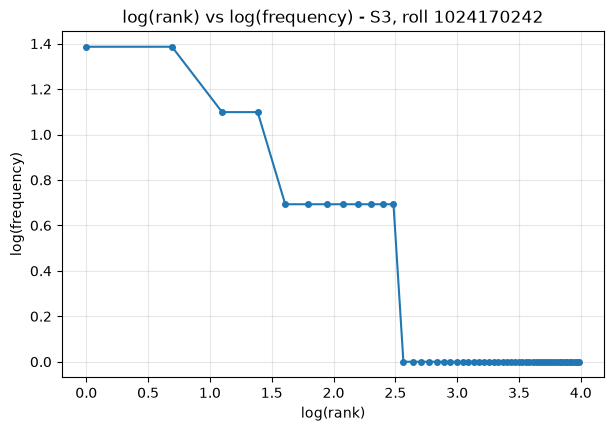

In [20]:
freqs = sorted(Counter(S3).values(), reverse=True)
ranks = range(1, len(freqs) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot([math.log(r) for r in ranks], [math.log(f) for f in freqs], "o-", markersize=4)
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title(f"log(rank) vs log(frequency) - S3, roll {ROLL_NO}")
plt.grid(alpha=0.3)
plt.show()

The graph goes down roughly like Zipf's law says - few words (matlab, please, laptop, help) are repeated a lot and most words come only once (the flat part at 0). Since there are only 72 final tokens the graph is in steps and not a smooth line.

In [21]:
# bigrams taken per ticket so words from two different tickets don't get paired
bigrams_S1 = Counter(b for r in results.values() for b in nltk.bigrams(r["tokens"]))
bigrams_S3 = Counter(b for r in results.values() for b in nltk.bigrams(r["final"]))

print("Top 5 bigrams of S1:")
for b, c in bigrams_S1.most_common(5):
    print(f"  {b}  {c}")
print("\nTop 5 bigrams of S3:")
for b, c in bigrams_S3.most_common(5):
    print(f"  {b}  {c}")

Top 5 bigrams of S1:
  ('.', 'please')  4
  ('please', 'help')  3
  ('help', '.')  3
  ('the', 'matlab')  2
  ('crashes', 'while')  2

Top 5 bigrams of S3:
  ('please', 'help')  3
  ('crashes', 'opening')  2
  ('showing', 'error')  2
  ('matlab', 'crashes')  1
  ('opening', 'check')  1


**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:* TTR goes 0.529 -> 0.616 -> 0.750 -> 0.736. It goes up when punctuation and stopwords are removed because those repeat a lot, and goes down a bit after Porter because working and works both become work. (explained more in Q6 a)

---
## Q6. Interpretation

**(a) Why does TTR change from S1 to S4 in my dataset?**

*Your answer:* | Set | Tokens | Unique | TTR |
|---|---|---|---|
| S1 | 153 | 81 | 0.529 |
| S2 | 125 | 77 | 0.616 |
| S3 | 72 | 54 | 0.750 |
| S4 | 72 | 53 | 0.736 |

TTR = unique / total.

- S1 to S2: removed 28 punctuation tokens but they were only 4 different types (`.` alone is 24 of them), so TTR goes up.
- S2 to S3: stopwords like the (12), is (7), it (4) repeat a lot, removing them takes out many tokens but few unique ones, so TTR goes up the most here.
- S3 to S4: Porter doesn't remove tokens, but working and works both become work, so unique goes from 54 to 53 and TTR goes down slightly.

**(b) One example where word_tokenize() and my tokenizer differ.**

*Your answer:* T11 "It's not the laptop; it's the server." - word_tokenize gives `It`, `'s` while my tokenizer gives `It's`. word_tokenize uses Penn Treebank rules which split 's and n't from the word. My pattern allows an apostrophe inside a word so the contraction stays as one token.

**(c) One example where stemming produces an undesirable result.**

*Your answer:* Lancaster changes projector to project. These are two different words (a device vs a piece of work), so after stemming a search for "project" would match the projector ticket. Porter also gives non-words like changed -> chang, please -> pleas, slowly -> slowli.

**(d) One example where POS-aware lemmatization preserves meaning better than stemming.**

*Your answer:* changed (T05) is tagged VBD (verb, past tense), so the lemmatizer gives change, which is a proper word. Porter and Lancaster both give chang. Same with crashes -> crash and says -> say. The POS tag also matters: opening is tagged VBG here so it becomes open, but if it was a noun (like "a job opening") the lemmatizer would keep opening, a stemmer would always cut it.